In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder

In [7]:
#load dataset
train = pd.read_csv('c:\\Users\\USER\\Desktop\\DATA VIS\\Data Visualization Project\\datasets\\student_addiction_dataset_train.csv')
test = pd.read_csv('c:\\Users\\USER\\Desktop\\DATA VIS\\Data Visualization Project\\datasets\\student_addiction_dataset_test.csv')
print("train dataset shape:" , train.shape)
print("test dataset shape:", test.shape)

train dataset shape: (50342, 11)
test dataset shape: (12744, 11)


In [8]:
train.head()
train.info()
train.describe()
train.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50342 entries, 0 to 50341
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Experimentation                     47780 non-null  object
 1   Academic_Performance_Decline        47844 non-null  object
 2   Social_Isolation                    47792 non-null  object
 3   Financial_Issues                    47805 non-null  object
 4   Physical_Mental_Health_Problems     47888 non-null  object
 5   Legal_Consequences                  47766 non-null  object
 6   Relationship_Strain                 47799 non-null  object
 7   Risk_Taking_Behavior                47765 non-null  object
 8   Withdrawal_Symptoms                 47730 non-null  object
 9   Denial_and_Resistance_to_Treatment  47889 non-null  object
 10  Addiction_Class                     50342 non-null  object
dtypes: object(11)
memory usage: 4.2+ MB


(50342, 11)

In [9]:
#drop duplicates
train = train.drop_duplicates()

In [10]:
#handling missing values
train.fillna("Unknown", inplace=True)

In [11]:
#standardize
for col in train.columns:
    train[col] = train[col].astype(str).str.strip().str.title()

In [12]:
#cleaned dataset
train.to_csv("student_addiction_dataset_train_cleaned.csv", index=False)

In [13]:
#contigency table
pd.crosstab(train["Social_Isolation"],
            train["Addiction_Class"])

Addiction_Class,No,Yes
Social_Isolation,,
No,3694,2332
Unknown,1049,592
Yes,3678,2411


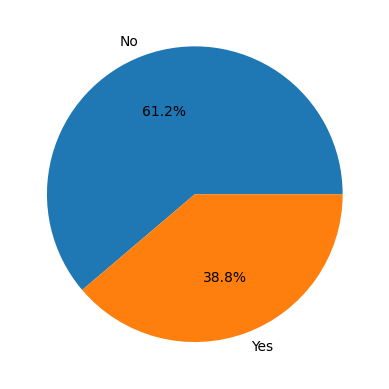

In [14]:
#addiction class distribution pie chart
train["Addiction_Class"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.show()

In [15]:
#chi square test of independence
table = pd.crosstab(train["Social_Isolation"], train["Addiction_Class"])
chi2,p,dof,expected = chi2_contingency(table)
print(p)

0.03371542442961264


In [17]:
#chi square test of independence for multiple categories
features = [
    "Experimentation",
    "Financial_Issues",
    "Withdrawal_Symptoms",
    "Relationship_Strain",
    "Risk_Taking_Behavior",
    "Academic_Performance_Decline"
]

for feature in features:
    table = pd.crosstab(train[feature], train["Addiction_Class"])
    chi2, p, dof, expected = chi2_contingency(table)

    print(f"\nFeature: {feature}")
    print(f"Chi-square Statistic: {chi2:.2f}")
    print(f"P-value: {p:.4f}")

    if p < 0.05:
        print("Result: Significant association with Addiction_Class")
    else:
        print("Result: No significant association with Addiction_Class")


Feature: Experimentation
Chi-square Statistic: 11.67
P-value: 0.0029
Result: Significant association with Addiction_Class

Feature: Financial_Issues
Chi-square Statistic: 10.64
P-value: 0.0049
Result: Significant association with Addiction_Class

Feature: Withdrawal_Symptoms
Chi-square Statistic: 5.41
P-value: 0.0670
Result: No significant association with Addiction_Class

Feature: Relationship_Strain
Chi-square Statistic: 19.42
P-value: 0.0001
Result: Significant association with Addiction_Class

Feature: Risk_Taking_Behavior
Chi-square Statistic: 19.01
P-value: 0.0001
Result: Significant association with Addiction_Class

Feature: Academic_Performance_Decline
Chi-square Statistic: 9.18
P-value: 0.0101
Result: Significant association with Addiction_Class


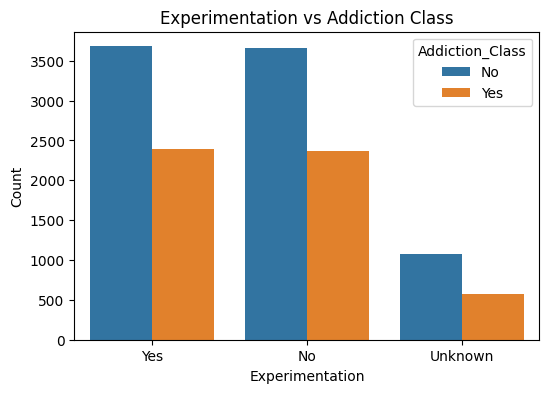

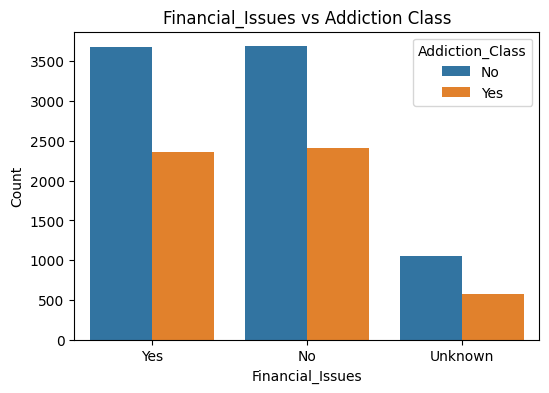

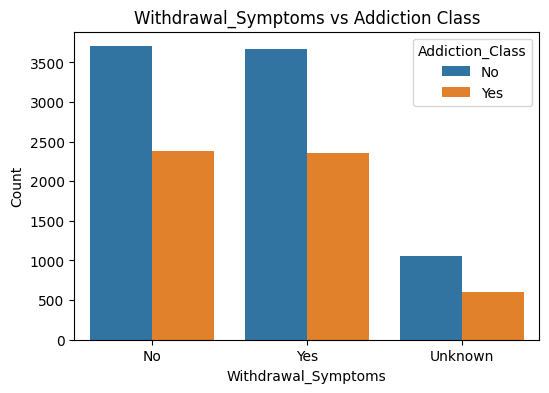

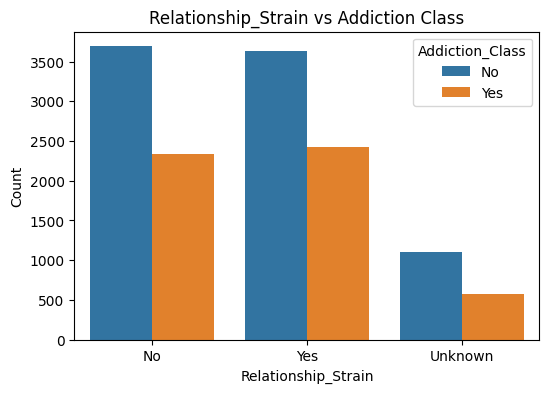

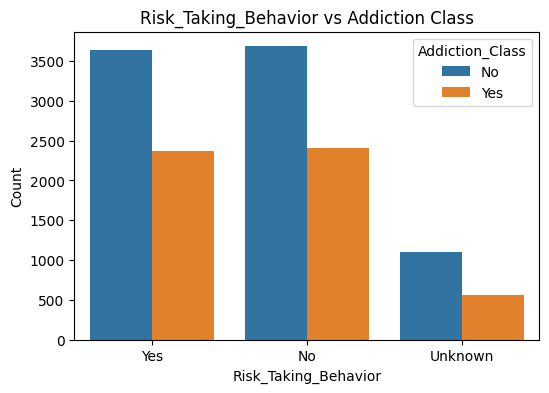

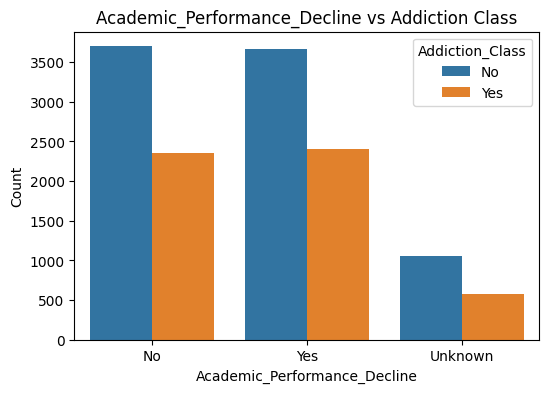

In [18]:
#count plot
features = [
    "Experimentation",
    "Financial_Issues",
    "Withdrawal_Symptoms",
    "Relationship_Strain",
    "Risk_Taking_Behavior",
    "Academic_Performance_Decline"
]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.countplot(data=train, x=feature, hue="Addiction_Class")
    plt.title(f"{feature} vs Addiction Class")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()

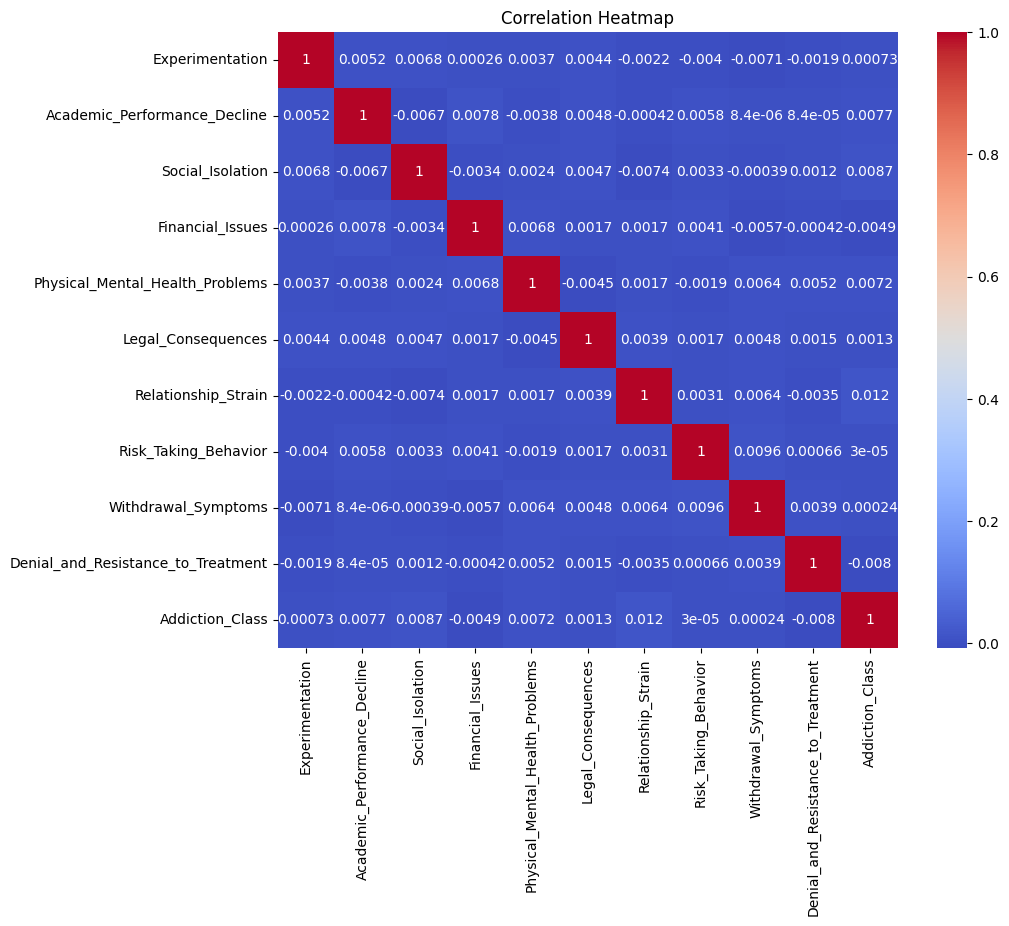

In [19]:
#correlation heatmap
encoded = train.apply(LabelEncoder().fit_transform)

plt.figure(figsize=(10,8))
sns.heatmap(encoded.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()